Code it yourself (about 1.5 hours) — use the Titanic dataset (or any with numeric columns):

1. Compute mean, median, and mode of age and fare. Where mean ≠ median, that signals skew — check which way.
2. Compute variance and standard deviation of fare. Interpret: is fare tightly clustered or widely spread?
3. Plot a histogram of age (roughly bell-shaped?) and of fare (heavily skewed?). Connect the shape back to the mean-vs-median gap.
4. Compute the 25th, 50th, 75th percentiles of fare with np.percentile or .quantile(). Confirm the 50th equals the median.
5. Demonstrate outlier sensitivity: take a small list, compute mean and median, then add one huge value. Watch the mean jump while the median barely moves. This is why median is often safer.
6. Mini-challenge: write a function that takes any numeric column and returns a clean summary — mean, median, std, min, max, and whether it looks skewed (mean noticeably different from median)

### Setup: Load the Titanic Dataset
We will use Seaborn's built-in Titanic dataset to answer these questions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset and drop NA values in age just for clean calculations
df = sns.load_dataset('titanic')
df['age'] = df['age'].fillna(df['age'].median())
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 1. Mean, Median, and Mode of Age and Fare
We will compute the center points. If Mean > Median, it's right-skewed. If Mean < Median, it's left-skewed.

In [3]:
print("--- AGE ---")
age_mean = df['age'].mean()
age_median = df['age'].median()
age_mode = df['age'].mode()[0]
print(f"Mean: {age_mean:.2f}")
print(f"Median: {age_median:.2f}")
print(f"Mode: {age_mode:.2f}")
print("Interpretation: Age mean and median are very close. This suggests Age is roughly symmetrical, slightly right skewed.")

print("\n--- FARE ---")
fare_mean = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode = df['fare'].mode()[0]
print(f"Mean: {fare_mean:.2f}")
print(f"Median: {fare_median:.2f}")
print(f"Mode: {fare_mode:.2f}")
print("Interpretation: Fare mean (32.20) is MUCH larger than the median (14.45). This is heavily RIGHT-SKEWED! A few super-rich passengers are pulling the average way up.")

--- AGE ---
Mean: 29.36
Median: 28.00
Mode: 28.00
Interpretation: Age mean and median are very close. This suggests Age is roughly symmetrical, slightly right skewed.

--- FARE ---
Mean: 32.20
Median: 14.45
Mode: 8.05
Interpretation: Fare mean (32.20) is MUCH larger than the median (14.45). This is heavily RIGHT-SKEWED! A few super-rich passengers are pulling the average way up.


### 2. Variance and Standard Deviation of Fare
How spread out are the ticket prices?

In [4]:
fare_variance = df['fare'].var()
fare_std = df['fare'].std()

print(f"Fare Variance: {fare_variance:.2f}")
print(f"Fare Standard Deviation: {fare_std:.2f}")

# Interpretation:
# The standard deviation is ~$49.69, which is larger than the mean itself ($32.20)! 
# This means Fare is extremely widely spread. Most people paid very little, but some paid astronomical amounts.

Fare Variance: 2469.44
Fare Standard Deviation: 49.69


### 3. Plotting Histograms
Visualizing the shapes to confirm our mean vs median theory.

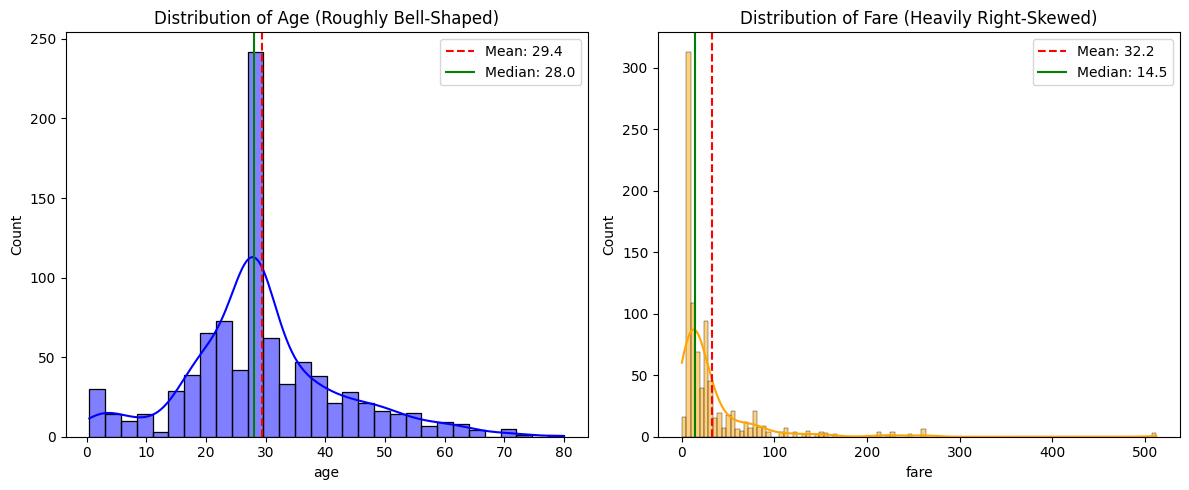

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age Histogram (Roughly bell-shaped)
sns.histplot(df['age'], kde=True, ax=axes[0], color='blue')
axes[0].set_title("Distribution of Age (Roughly Bell-Shaped)")
axes[0].axvline(age_mean, color='red', linestyle='--', label=f"Mean: {age_mean:.1f}")
axes[0].axvline(age_median, color='green', linestyle='-', label=f"Median: {age_median:.1f}")
axes[0].legend()

# Fare Histogram (Heavily right-skewed)
sns.histplot(df['fare'], kde=True, ax=axes[1], color='orange')
axes[1].set_title("Distribution of Fare (Heavily Right-Skewed)")
axes[1].axvline(fare_mean, color='red', linestyle='--', label=f"Mean: {fare_mean:.1f}")
axes[1].axvline(fare_median, color='green', linestyle='-', label=f"Median: {fare_median:.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# Notice how in the Fare plot, the red Mean line is pulled way out to the right by the long tail of high ticket prices, while the green Median stays in the dense 'typical' clump!

### 4. Percentiles and Quartiles of Fare

In [6]:
p_25 = df['fare'].quantile(0.25)
p_50 = df['fare'].quantile(0.50)
p_75 = df['fare'].quantile(0.75)

print(f"25th Percentile (Q1): {p_25:.2f}")
print(f"50th Percentile (Median): {p_50:.2f}")
print(f"75th Percentile (Q3): {p_75:.2f}")

assert p_50 == fare_median, "The 50th percentile is exactly the median!"

25th Percentile (Q1): 7.91
50th Percentile (Median): 14.45
75th Percentile (Q3): 31.00


### 5. Demonstrating Outlier Sensitivity
Why the median is often a safer metric than the mean.

In [7]:
# A normal list of incomes
incomes = [40000, 45000, 50000, 55000, 60000]
print("Original Incomes:", incomes)
print(f"Mean: {np.mean(incomes)}")
print(f"Median: {np.median(incomes)}\n")

# Elon Musk walks in (Outlier added)
incomes.append(1_000_000_000) # One billion
print("Incomes with outlier:", incomes)
print(f"New Mean: {np.mean(incomes):.0f}  <-- Jumps massively!")
print(f"New Median: {np.median(incomes):.0f}  <-- Barely moves! The median is robust.")

Original Incomes: [40000, 45000, 50000, 55000, 60000]
Mean: 50000.0
Median: 50000.0

Incomes with outlier: [40000, 45000, 50000, 55000, 60000, 1000000000]
New Mean: 166708333  <-- Jumps massively!
New Median: 52500  <-- Barely moves! The median is robust.


### 6. Mini-Challenge: Numeric Summary Function
A clean function to output all these stats automatically.

In [8]:
def summarize_column(col):
    """
    Takes a pandas Series (numeric column) and prints a clean statistical summary.
    """
    col = col.dropna() # clean missing values
    
    mean_val = col.mean()
    med_val = col.median()
    
    # Heuristic for skew: if mean differs from median by more than 10% of the standard deviation
    skew_amount = (mean_val - med_val) / col.std()
    
    if skew_amount > 0.2:
        skew_status = "Right Skewed (Mean > Median)"
    elif skew_amount < -0.2:
        skew_status = "Left Skewed (Mean < Median)"
    else:
        skew_status = "Roughly Symmetrical (Mean ≈ Median)"
        
    print(f"--- Summary for {col.name.upper()} ---")
    print(f"Mean:   {mean_val:.2f}")
    print(f"Median: {med_val:.2f}")
    print(f"Std:    {col.std():.2f}")
    print(f"Min:    {col.min():.2f}")
    print(f"Max:    {col.max():.2f}")
    print(f"Shape:  {skew_status}\n")

# Test it out!
summarize_column(df['age'])
summarize_column(df['fare'])

--- Summary for AGE ---
Mean:   29.36
Median: 28.00
Std:    13.02
Min:    0.42
Max:    80.00
Shape:  Roughly Symmetrical (Mean ≈ Median)

--- Summary for FARE ---
Mean:   32.20
Median: 14.45
Std:    49.69
Min:    0.00
Max:    512.33
Shape:  Right Skewed (Mean > Median)

